## PHẦN 1: TIỀN XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU

### Câu 1: Nạp và Khám phá dữ liệu

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nạp bộ dữ liệu titanic có sẵn trong seaborn
df = sns.load_dataset('titanic')

# In ra 5 dòng đầu tiên
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
# Thông tin tổng quan của dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### Câu 2: Xử lý giá trị khuyết

In [3]:
# Đếm số lượng giá trị khuyết ở mỗi cột
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [4]:
# Xóa cột 'deck' vì có quá nhiều giá trị khuyết
df.drop(columns=['deck'], inplace=True)
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [5]:
# Điền giá trị khuyết của cột 'age' bằng giá trị trung bình (mean)
df['age'].fillna(df['age'].mean(), inplace=True)

# Kiểm tra lại
df['age'].isnull().sum()

/tmp/ipykernel_1876/2302463135.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


np.int64(0)

### Câu 3: Phân tích và Trực quan hóa

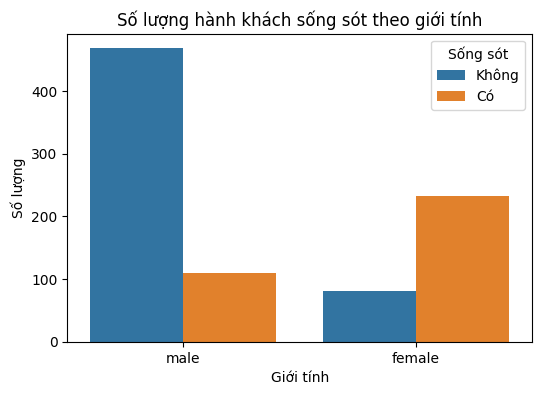

In [6]:
# Biểu đồ số lượng hành khách sống sót theo giới tính
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Số lượng hành khách sống sót theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.legend(title='Sống sót', labels=['Không', 'Có'])
plt.show()

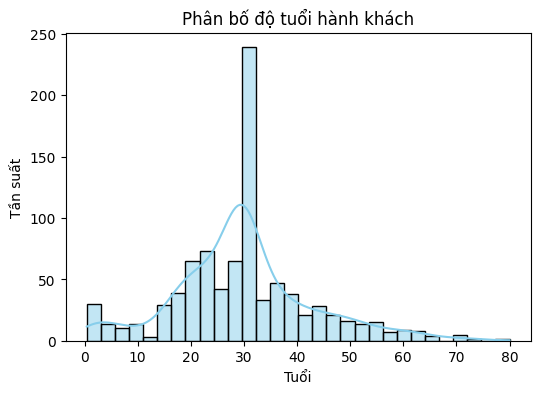

In [7]:
# Biểu đồ phân bố độ tuổi hành khách
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True, bins=30, color='skyblue')
plt.title('Phân bố độ tuổi hành khách')
plt.xlabel('Tuổi')
plt.ylabel('Tần suất')
plt.show()

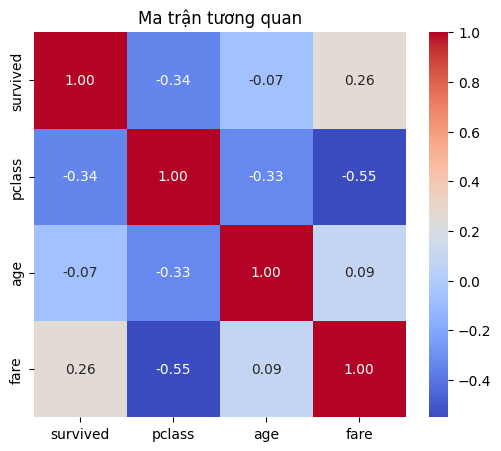

In [8]:
# Ma trận tương quan giữa các biến số
numeric_cols = ['survived', 'pclass', 'age', 'fare']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan')
plt.show()

### Câu 4: Mã hóa dữ liệu

In [9]:
# Label Encoding cho cột 'sex': male -> 0, female -> 1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df[['sex']].head()

,sex
0,0
1,1
2,1
3,1
4,0


In [10]:
# One-Hot Encoding cho cột 'embarked'
embarked_dummies = pd.get_dummies(df['embarked'], prefix='embarked')
df = pd.concat([df, embarked_dummies], axis=1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,False,False,True
1,1,1,1,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,True,False,False
2,1,3,1,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,1,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,0,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,False,False,True


## PHẦN 2: XÂY DỰNG MÔ HÌNH HỌC SÂU CƠ BẢN

### Câu 5: Chuẩn bị dữ liệu cho Học sâu

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Tạo X (đặc trưng) và y (nhãn)
X = df[['pclass', 'sex', 'age']]
y = df['survived']

# Chia tập train/test theo tỷ lệ 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Kích thước X_train:', X_train.shape)
print('Kích thước X_test:', X_test.shape)

Kích thước X_train: (712, 3)
Kích thước X_test: (179, 3)


In [12]:
# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-1.61413602, -0.7243102 ,  1.22920747],
       [-0.40055118, -0.7243102 , -0.50350514],
       [ 0.81303367, -0.7243102 ,  0.18957991],
       [ 0.81303367, -0.7243102 , -0.27247679],
       [ 0.81303367,  1.38062393, -1.81266577]])

### Câu 6: Xây dựng mạng Nơ-ron nhân tạo (ANN)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Khởi tạo mô hình Sequential
model = Sequential()

# Lớp ẩn: 16 nơ-ron, hàm kích hoạt relu, input_shape = số đặc trưng (3)
model.add(Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Lớp đầu ra: 1 nơ-ron, hàm kích hoạt sigmoid (phân loại nhị phân)
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compile mô hình
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [15]:
# Huấn luyện mô hình với 20 epochs
history = model.fit(X_train_scaled, y_train,
                     epochs=20,
                     batch_size=16,
                     validation_split=0.1,
                     verbose=1)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6625 - loss: 0.6409 - val_accuracy: 0.8194 - val_loss: 0.5884
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7672 - loss: 0.5886 - val_accuracy: 0.8611 - val_loss: 0.5255
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7859 - loss: 0.5538 - val_accuracy: 0.8750 - val_loss: 0.4765
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7859 - loss: 0.5271 - val_accuracy: 0.8750 - val_loss: 0.4417
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7781 - loss: 0.5080 - val_accuracy: 0.8750 - val_loss: 0.4138
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7750 - loss: 0.4944 - val_accuracy: 0.8889 - val_loss: 0.3916
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7859 - loss: 0.4850 - val_accuracy: 0.8889 - val_loss: 0.3767
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7812 - loss: 0.4781 - val_accuracy: 0.8889 - val_los

In [16]:
# Đánh giá mô hình trên tập test
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.4446
Test Accuracy: 0.7989
